# DECOMP — Mutable Line Limits
## Applied to IEEE 14-bus, IEEE 39-bus, IEEE 57-bus

**Algorithm:** DECOMP (Column-and-Constraint Generation, Yue et al. 2019) adapted for b-parameter counterfactual explanations in UC.

Objective: find minimum change to line flow limits b such that the 20% emissions-reduction foil becomes UC-optimal.


In [1]:
import sys
print(sys.executable)


c:\Users\PC3\miniconda3\envs\CE_exp311\python.exe


## 0 · Imports and helpers

In [2]:
import os, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import replace

import gurobipy as gp
from gurobipy import GRB

#os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"

import uc_pipeline, uc_data_loader, uc_branch_sandwich_4b, uc_master_relax_4b, uc_decomp_4b
importlib.reload(uc_pipeline)
importlib.reload(uc_data_loader)
importlib.reload(uc_branch_sandwich_4b)
importlib.reload(uc_master_relax_4b)
importlib.reload(uc_decomp_4b)

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
    make_emissions_foil_4b,
    set_objective_from_cvec,
)
from uc_data_loader import quick_setup
from uc_decomp_4b import UCDecomp4b
from uc_branch_sandwich_4b import UCBranchAndSandwichWCE_4b

# Color palette for dispatch stacked-area plots (matches BranchSand_3grids.ipynb)
TECH_COLORS = ["#73726c","#378ADD","#BA7517","#7F77DD","#1D9E75",
               "#D85A30","#639922","#5DCAA5","#EF9F27","#E24B4A"]


# ── Data folder ───────────────────────────────────────────────────────────
#DATA_DIR = r"C:\Users\tomas\Documents\GitHub\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"
DATA_DIR = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"
ALPHA    = 0.10   # 10% emissions reduction (matches bs_7grids.ipynb)
UTIL_THR = 0.75   # congestion threshold
warnings.filterwarnings("ignore")
print("Imports OK")
print(f"alpha={ALPHA:.0%}  UTIL_THR={UTIL_THR:.0%}")


Imports OK
alpha=10%  UTIL_THR=75%


### Helpers (oracle, line-limit utilities)

In [3]:
def replace_line_limits(data, b_line):
    b_line = np.asarray(b_line, dtype=float).reshape(-1)
    new_lines = [replace(L, fmax=float(b_line[ell])) for ell, L in enumerate(data.lines)]
    return replace(data, lines=new_lines)


def get_congested_free_lines(sol0, b0, thr=0.75):
    f_abs_max = np.max(np.abs(sol0['f']), axis=1)
    util      = f_abs_max / np.maximum(b0, 1e-9)
    idx_cong  = [ell for ell in range(len(b0)) if util[ell] >= thr]
    if not idx_cong:
        idx_cong = [int(np.argmax(util))]
    return idx_cong, util


def build_b_bounds(b0, b_free_idx, scale_up=1.2):
    bL = b0.copy(); bU = b0.copy()
    for ell in b_free_idx:
        bU[ell] = scale_up * b0[ell]
    return bL, bU


def make_line_weights(DATA, b0, util=None, alpha=1.0, beta=1.0, gamma=0.5, eps_u=0.05):
    b_susc  = np.array([float(L.b) for L in DATA.lines], dtype=float)
    x_proxy = 1.0 / np.maximum(np.abs(b_susc), 1e-9)
    w = (x_proxy / max(np.median(x_proxy), 1e-9))**alpha
    w *= (b0 / max(np.median(b0), 1e-9))**beta
    if util is not None:
        w *= (1.0 / (eps_u + util))**gamma
    w = w / np.mean(w)
    return np.clip(w, 0.1, 10.0)


class UCWeakWCEOracle:
    def __init__(self, data, cvec, idx, window_size, per_bus_neutrality,
                 u_init, p_init, on_t, off_t,
                 foil_extra_constr_fn=None, output_flag=0, time_limit=None, cache_decimals=3):
        self.data = data
        self.cvec = np.asarray(cvec, float)
        self.idx  = idx
        self.window_size        = int(window_size)
        self.per_bus_neutrality = bool(per_bus_neutrality)
        self.u_init = u_init; self.p_init = p_init
        self.on_t = on_t;     self.off_t  = off_t
        self.foil_extra_constr_fn = foil_extra_constr_fn
        self.output_flag    = int(output_flag)
        self.time_limit     = time_limit
        self.cache_decimals = int(cache_decimals)
        self.cache_plain = {}
        self.cache_foil  = {}

    def _key(self, b):
        return tuple(np.round(np.asarray(b, float), self.cache_decimals))

    def _solve(self, b, extra_fn, cache):
        key = self._key(b)
        if key in cache:
            return cache[key]
        data_b = replace_line_limits(self.data, b)
        _, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size,
            per_bus_neutrality=self.per_bus_neutrality,
            u_init=self.u_init, p_init=self.p_init,
            on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=extra_fn,
            output_flag=self.output_flag, time_limit=self.time_limit,
        )
        out = (None, None, None) if sol is None else (float(sol['obj']), np.array(z, float), sol)
        cache[key] = out
        return out

    def solve_plain(self, b): return self._solve(b, None, self.cache_plain)
    def solve_foil(self, b):  return self._solve(b, self.foil_extra_constr_fn, self.cache_foil)


print("Helpers defined.")


Helpers defined.


### Plot helper (`plot_decomp_results`)

In [4]:
def plot_decomp_results(DATA, b0, b_hat, sol0, sol_plain_hat, sol_foil_hat,
                         res, label="", foil_label="emissions −0%", method="DECOMP"):
    """4-panel summary figure for a DECOMP run.
    Ported from BranchSand_3grids.ipynb's plot_bs_results to consume the
    DECOMP result dict (which uses the same `success`, `b_hat`, `F_opt`,
    `master_LB`, `certified` fields).
    """
    if res is None or not res.get('success'):
        print(f'[{label}] No successful result — nothing to plot.')
        return
    nG = len(DATA.gens); nR = len(DATA.rens); T = int(DATA.T); nL = len(DATA.lines)
    hrs = np.arange(T)
    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(f'{method} — {label}   [foil: {foil_label}]', fontsize=13, fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.28)
    ax1, ax2, ax3, ax4 = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])

    def _dispatch_panel(ax, sol, title):
        if sol is None:
            ax.set_title(f'{title} (N/A)'); return
        p_raw = sol['p']
        if isinstance(p_raw, dict):
            p_mat = np.array([[float(p_raw[g, t]) for t in range(T)] for g in range(nG)])
        else:
            p_mat = np.asarray(p_raw, dtype=float)
            if p_mat.shape == (T, nG): p_mat = p_mat.T
        sol = dict(sol, p=p_mat)
        bottom = np.zeros(T)
        for g in range(nG):
            col = TECH_COLORS[g % len(TECH_COLORS)]
            ax.fill_between(hrs, bottom, bottom + sol['p'][g], color=col, alpha=0.75, label=f'G{g}', step='mid')
            bottom += sol['p'][g]
        if nR > 0 and 'curt' in sol:
            avail = np.vstack([r.avail for r in DATA.rens])
            ren_inj = (avail - sol['curt']).sum(axis=0)
            ax.fill_between(hrs, bottom, bottom + ren_inj, color='#1D9E75', alpha=0.5, label='Renewable', step='mid')
            bottom += ren_inj
        ax.plot(hrs, bottom, color='orange', lw=1.8, label='Total production', zorder=5)
        ax.plot(hrs, DATA.demand.sum(axis=0), 'k--', lw=1.5, label='Demand')
        ax.set_title(title, fontsize=10); ax.set_xlabel('Hour'); ax.set_ylabel('MW')
        ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=4, loc='upper left')

    _dispatch_panel(ax1, sol0,         'Factual dispatch  (b = b₀)')
    _dispatch_panel(ax2, sol_foil_hat, 'Counterfactual dispatch  (b = b̂, foil active)')

    curtF  = sol0['curt'].sum(axis=0) if nR>0 and 'curt' in sol0 else np.zeros(T)
    curtCF = sol_foil_hat['curt'].sum(axis=0) if sol_foil_hat is not None and nR>0 and 'curt' in sol_foil_hat else np.zeros(T)
    curtP  = sol_plain_hat['curt'].sum(axis=0) if sol_plain_hat is not None and nR>0 and 'curt' in sol_plain_hat else np.zeros(T)
    ax3.bar(hrs-0.27, curtF,  0.26, color='#D85A30', alpha=0.85, label=f'Factual  ({curtF.sum():.1f} MWh)')
    ax3.bar(hrs,      curtP,  0.26, color='#BA7517', alpha=0.85, label=f'Plain@b̂  ({curtP.sum():.1f} MWh)')
    ax3.bar(hrs+0.27, curtCF, 0.26, color='#378ADD', alpha=0.85, label=f'Foil@b̂   ({curtCF.sum():.1f} MWh)')
    ax3.set_title('Curtailment per hour (MWh)', fontsize=10)
    ax3.set_xlabel('Hour'); ax3.set_ylabel('MWh'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y')

    b_hat_pu = b_hat / np.maximum(b0, 1e-12)
    changed  = np.where(np.abs(b_hat_pu - 1.0) > 1e-4)[0]
    x_all    = np.arange(nL)
    ax4.bar(x_all, b_hat_pu, color='#cccccc', alpha=0.6, label='Unchanged')
    if len(changed):
        ax4.bar(changed, b_hat_pu[changed], color='#378ADD', alpha=0.9, label='Changed')
    ax4.axhline(1.0, color='k', lw=1.0, ls='--', label='Original (1.0 p.u.)')
    ax4.set_title('Line limits — counterfactual vs original  (p.u.)', fontsize=10)
    ax4.set_xlabel('Line index ℓ'); ax4.set_ylabel('b̂ / b₀  (p.u.)')
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='y')
    ax4.text(0.98, 0.97, f'{len(changed)} line(s) changed', transform=ax4.transAxes, ha='right', va='top', fontsize=8)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

    F_best = float(res.get('F_opt', np.nan))
    LB     = float(res.get('master_LB', np.nan))
    gap_pct = (100.0 * max(0.0, F_best - LB) / abs(F_best)
               if np.isfinite(F_best) and np.isfinite(LB) and abs(F_best) > 1e-12 else np.nan)
    print(f'\n{label} — {method} summary:')
    print(f'  Iterations       : {res.get("iterations")}')
    print(f'  Patterns added   : {res.get("seen_patterns")}')
    print(f'  F_opt (incumbent): {F_best:.6f}')
    print(f'  Master LB        : {LB:.6f}')
    print(f'  Gap              : {gap_pct:.3f}%')
    print(f'  Certified        : {res.get("certified")}')
    print(f'  Termination      : {res.get("termination_reason")}')
    cand = res.get('candidate')
    if cand is not None and cand.get('F') is not None and cand['F'] < F_best - 1e-9:
        print(f'  [candidate] master also found b with F={cand["F"]:.4f} (oracle_ce_gap={cand.get("oracle_ce_gap")}) — not certified')
    if len(changed):
        delta_abs = b_hat - b0
        delta_pu  = delta_abs / np.maximum(b0, 1e-12)
        util_arr  = np.max(np.abs(sol0['f']), axis=1) / np.maximum(b0, 1e-9)
        print(f"  {'ell':>4}  {'fr->to':>6}  {'b0(MW)':>9}  {'b_hat(MW)':>10}  {'Δ(MW)':>8}  {'b_hat(pu)':>10}  {'Δ(pu)':>8}  {'util':>6}")
        rows = sorted([(ell, int(DATA.lines[ell].fr), int(DATA.lines[ell].to),
                        b0[ell], b_hat[ell], delta_abs[ell], b_hat_pu[ell], delta_pu[ell], util_arr[ell])
                       for ell in changed], key=lambda r: -abs(r[7]))
        for ell, fr, to, b0v, bhv, dv, bhpu, dpu, uti in rows:
            print(f'  {ell:>4}  {fr:>2}->{to:<3}  {b0v:>9.3f}  {bhv:>10.3f}  {dv:>8.3f}  {bhpu:>10.3f}  {dpu:>+8.3f}  {uti:>6.3f}')
    else:
        print('  (No line limits changed.)')

print('plot_decomp_results defined.')


plot_decomp_results defined.


---
## Section 1 · Dataset loading

In [5]:
DATA_14, idx_14, cvec_14, b0_14, u_init_14, p_init_14, on_t_14, off_t_14 = quick_setup(
    os.path.join(DATA_DIR, "ieee14_enhanced.json"),
    carbon_price=None, voll=20_000.0, slack_bus=None,
)
print(f"IEEE 14-bus  buses={DATA_14.nB}  lines={len(DATA_14.lines)}  gens={len(DATA_14.gens)}  T={int(DATA_14.T)}h")


Loaded: ieee14_enhanced.json
  Buses: 14  |  Lines: 20  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 648.4 MW
  Total renewable capacity: 570.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 14-bus  buses=14  lines=20  gens=6  T=24h


In [6]:
DATA_39, idx_39, cvec_39, b0_39, u_init_39, p_init_39, on_t_39, off_t_39 = quick_setup(
    os.path.join(DATA_DIR, "ieee39_newengland.json"),
    carbon_price=None, voll=20_000.0, slack_bus=None,
    demand_scaling=1, ren_scaling=1.0,
)
print(f"IEEE 39-bus  buses={DATA_39.nB}  lines={len(DATA_39.lines)}  gens={len(DATA_39.gens)}  T={int(DATA_39.T)}h")


Loaded: ieee39_newengland.json
  Buses: 39  |  Lines: 46  |  T: 24h
  Generators: 10  |  Renewables: 4
  System peak demand: 2656.4 MW
  Total renewable capacity: 1900.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 39-bus  buses=39  lines=46  gens=10  T=24h


In [7]:
DATA_57, idx_57, cvec_57, b0_57, u_init_57, p_init_57, on_t_57, off_t_57 = quick_setup(
    os.path.join(DATA_DIR, "ieee57_uc_matpower.json"),
    carbon_price=50.0, voll=500.0, slack_bus=0,
    ren_scaling=1.0, demand_scaling=1.0,
)
u_init_57 = [0]*len(DATA_57.gens); p_init_57 = [0.0]*len(DATA_57.gens)
on_t_57   = [0]*len(DATA_57.gens); off_t_57  = [0]*len(DATA_57.gens)
# Warm-start G0 exactly as in bs_7grids.ipynb
u_init_57[0]=1; p_init_57[0]=DATA_57.gens[0].Pmax; on_t_57[0]=DATA_57.gens[0].UT
print(f"IEEE 57-bus  buses={DATA_57.nB}  lines={len(DATA_57.lines)}  gens={len(DATA_57.gens)}  T={int(DATA_57.T)}h")


Loaded: ieee57_uc_matpower.json
  Buses: 57  |  Lines: 76  |  T: 24h
  Generators: 8  |  Renewables: 5
  System peak demand: 1000.0 MW
  Total renewable capacity: 976.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 57-bus  buses=57  lines=76  gens=8  T=24h


---
## Section 2 · Factual UC and emissions baseline

In [8]:
_, solF_14, zF_14 = solve_uc_with_cost_4b(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14, output_flag=0,
)
assert solF_14 is not None
e_14         = np.array([float(gen.emission_rate) for gen in DATA_14.gens])
E_factual_14 = float(np.sum(e_14[:, None] * solF_14['p']))
foil_fn_14   = make_emissions_foil_4b(DATA_14, alpha=ALPHA, E_factual=E_factual_14)
b_free_idx_14, util_14 = get_congested_free_lines(solF_14, b0_14, thr=UTIL_THR)
bL_14, bU_14 = build_b_bounds(b0_14, b_free_idx_14)
w_14          = make_line_weights(DATA_14, b0_14, util=util_14)
oracle_14     = UCWeakWCEOracle(
    data=DATA_14, cvec=cvec_14, idx=idx_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,
    foil_extra_constr_fn=foil_fn_14, output_flag=0,
)
vF_14, _, solFoil_b0_14 = oracle_14.solve_foil(b0_14)
print(f"IEEE 14-bus  E_factual={E_factual_14:.2f} tCO2  target={(1-ALPHA)*E_factual_14:.2f}  foil_at_b0={'feas' if solFoil_b0_14 else 'infeas'}  free={len(b_free_idx_14)} lines")


Set parameter Username
Set parameter LicenseID to value 2794356
Academic license - for non-commercial use only - expires 2027-03-18
IEEE 14-bus  E_factual=6797.10 tCO2  target=6117.39  foil_at_b0=feas  free=6 lines


In [9]:
foil_fn_14_base = foil_fn_14
def foil_fn_14(m, var):
    foil_fn_14_base(m, var)
    m.addConstr(
        gp.quicksum(var['shed'][b, t]
                    for b in range(DATA_14.nB)
                    for t in range(int(DATA_14.T))) == 0,
        name='foil_no_shed')
oracle_14.foil_extra_constr_fn = foil_fn_14
oracle_14.cache_foil.clear()
vF_14, _, solFoil_b0_14 = oracle_14.solve_foil(b0_14)
print(f"IEEE 14 foil_no_shed: foil_at_b0={'feas' if solFoil_b0_14 else 'infeas'}")


IEEE 14 foil_no_shed: foil_at_b0=infeas


In [10]:
_, solF_39, zF_39 = solve_uc_with_cost_4b(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39, output_flag=0,
)
assert solF_39 is not None
e_39         = np.array([float(gen.emission_rate) for gen in DATA_39.gens])
E_factual_39 = float(np.sum(e_39[:, None] * solF_39['p']))
foil_fn_39   = make_emissions_foil_4b(DATA_39, alpha=ALPHA, E_factual=E_factual_39)
b_free_idx_39, util_39 = get_congested_free_lines(solF_39, b0_39, thr=UTIL_THR)
bL_39, bU_39 = build_b_bounds(b0_39, b_free_idx_39)
w_39          = make_line_weights(DATA_39, b0_39, util=util_39)
oracle_39     = UCWeakWCEOracle(
    data=DATA_39, cvec=cvec_39, idx=idx_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,
    foil_extra_constr_fn=foil_fn_39, output_flag=0,
)
vF_39, _, solFoil_b0_39 = oracle_39.solve_foil(b0_39)
print(f"IEEE 39-bus  E_factual={E_factual_39:.2f} tCO2  target={(1-ALPHA)*E_factual_39:.2f}  foil_at_b0={'feas' if solFoil_b0_39 else 'infeas'}  free={len(b_free_idx_39)} lines")


IEEE 39-bus  E_factual=2144.04 tCO2  target=1929.64  foil_at_b0=feas  free=10 lines


In [11]:
_, solF_57, zF_57 = solve_uc_with_cost_4b(
    data=DATA_57, idx=idx_57, cvec=cvec_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57, output_flag=0,
)
assert solF_57 is not None
e_57         = np.array([float(gen.emission_rate) for gen in DATA_57.gens])
E_factual_57 = float(np.sum(e_57[:, None] * solF_57['p']))
foil_fn_57   = make_emissions_foil_4b(DATA_57, alpha=ALPHA, E_factual=E_factual_57)
b_free_idx_57, util_57 = get_congested_free_lines(solF_57, b0_57, thr=UTIL_THR)
bL_57, bU_57 = build_b_bounds(b0_57, b_free_idx_57)
w_57          = make_line_weights(DATA_57, b0_57, util=util_57)
oracle_57     = UCWeakWCEOracle(
    data=DATA_57, cvec=cvec_57, idx=idx_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57, on_t=on_t_57, off_t=off_t_57,
    foil_extra_constr_fn=foil_fn_57, output_flag=0,
)
vF_57, _, solFoil_b0_57 = oracle_57.solve_foil(b0_57)
print(f"IEEE 57-bus  E_factual={E_factual_57:.2f} tCO2  target={(1-ALPHA)*E_factual_57:.2f}  foil_at_b0={'feas' if solFoil_b0_57 else 'infeas'}  free={len(b_free_idx_57)} lines")


IEEE 57-bus  E_factual=7195.70 tCO2  target=6476.13  foil_at_b0=feas  free=6 lines


---
## Section 3 · Big-M calibration

Estimate `big_M_mu` as 10× the maximum LP dual on fmax/fmin constraints at b₀.

In [12]:
def estimate_big_M_mu(DATA, idx, cvec, b0, u_init, p_init, on_t, off_t, multiplier=10.0):
    from uc_master_relax_4b import build_uc_relax_master_varfmax_4b
    bL = b0 * 0.5; bU = b0 * 2.0
    b_all = list(range(len(DATA.lines)))
    m, var, bcap = build_uc_relax_master_varfmax_4b(
        data=DATA, idx=idx, cvec=cvec,
        window_size=int(DATA.T), per_bus_neutrality=True,
        u_init=u_init, p_init=p_init, on_time_init=on_t, off_time_init=off_t,
        b0=b0, node_bL=bL, node_bU=bU, b_free_idx=b_all, output_flag=0,
    )
    set_objective_from_cvec(m, var, idx, cvec)
    m.optimize()
    max_pi = 0.0
    if m.Status == 2:
        for c in m.getConstrs():
            nm = c.ConstrName
            if nm.startswith("foil_fmax") or nm.startswith("fmax") or nm.startswith("fmin"):
                try: max_pi = max(max_pi, abs(c.Pi))
                except Exception: pass
    m.dispose()
    big_M = multiplier * max(max_pi, 1.0)
    print(f"  max|dual_fmax|={max_pi:.4f}  big_M_mu={big_M:.2f}")
    return big_M


print("Calibrating big-M ...")
big_M_mu_14 = estimate_big_M_mu(DATA_14, idx_14, cvec_14, b0_14, u_init_14, p_init_14, on_t_14, off_t_14)
big_M_mu_39 = estimate_big_M_mu(DATA_39, idx_39, cvec_39, b0_39, u_init_39, p_init_39, on_t_39, off_t_39)
big_M_mu_57 = estimate_big_M_mu(DATA_57, idx_57, cvec_57, b0_57, u_init_57, p_init_57, on_t_57, off_t_57)
print(f"big_M_mu: 14={big_M_mu_14:.1f}  39={big_M_mu_39:.1f}  57={big_M_mu_57:.1f}")


Calibrating big-M ...
  max|dual_fmax|=499.8312  big_M_mu=4998.31
  max|dual_fmax|=0.0000  big_M_mu=10.00
  max|dual_fmax|=80.6000  big_M_mu=806.00
big_M_mu: 14=4998.3  39=10.0  57=806.0


---
## Section 4a · Diagnostic — `debug_fix_b` with B&S solution

Two tests per grid, both with `b` fixed to the known CE `b_hat` from B&S and `comp_mode='bigM'` (matches Section 4b):

1. **Self-consistent** — KKT block built for `u^* = plain-optimal-at-b_hat`. Verifies formulation correctness; should always be feasible since `b_hat` IS a CE.
2. **Cross-pattern** — KKT block built for `u_1` (the pattern DECOMP discovers at Iter 1, from a *different* `b_1`).  This is the actual model DECOMP's run() solves at Iter 2 with `b` fixed.

**`cut_slack`** = `LP_cost(u^j, b_hat) − foil_cost` at the solution.  Tiny slack (< 1e-2) ⇒ the optimality cut is nearly binding at `b_hat`, so the feasible region is essentially a single point — B&B has to land on it exactly, which explains why Section 4b times out even though the formulation is correct.

### 4a.1 · IEEE 14-bus — self-consistent

In [ ]:
import json as _json
_cp_path = "bs_14_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a] IEEE 14: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_14, data=DATA_14, idx=idx_14, cvec=cvec_14,
        foil_extra_constr_fn=foil_fn_14,
        b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
        big_M_mu=big_M_mu_14, output_flag=0, verbose=True, w=w_14,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    _dbg = _tester.debug_fix_b(
        b_test=_b_bs,
        window_size=int(DATA_14.T), per_bus_neutrality=True,
        u_init=u_init_14, p_init=p_init_14,
        on_time_init=on_t_14, off_time_init=off_t_14,
        iis_path=f"debug_fix_b_14_self.ilp",
    )
    print(f"[4a] IEEE 14 self-consistent (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
    del _tester
else:
    print(f"[4a] No B&S checkpoint for IEEE 14 — skipping.")


### 4a.2 · IEEE 14-bus — cross-pattern (u_1 at b_hat)

In [ ]:
import json as _json
_cp_path = "bs_14_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a-cross] IEEE 14: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_14, data=DATA_14, idx=idx_14, cvec=cvec_14,
        foil_extra_constr_fn=foil_fn_14,
        b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
        big_M_mu=big_M_mu_14, output_flag=0, verbose=True, w=w_14,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    # Step 1: replicate Iter 1 of run() to get u_1
    _b_1, _u_1, _F_1 = _tester.iter1_pattern(
        window_size=int(DATA_14.T), per_bus_neutrality=True,
        u_init=u_init_14, p_init=p_init_14,
        on_time_init=on_t_14, off_time_init=off_t_14,
    )
    if _u_1 is None:
        print("[4a-cross] iter1_pattern failed — skipping.")
    else:
        # Step 2: test KKT block for u_1 with b fixed to b_hat
        _dbg = _tester.debug_fix_b(
            b_test=_b_bs, u_j_override=_u_1,
            window_size=int(DATA_14.T), per_bus_neutrality=True,
            u_init=u_init_14, p_init=p_init_14,
            on_time_init=on_t_14, off_time_init=off_t_14,
            iis_path=f"debug_fix_b_14_cross.ilp",
        )
        print(f"[4a-cross] IEEE 14 cross-pattern (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
        print(f"           interpretation: tiny cut_slack ⇒ b_hat is a corner of feasible region ⇒ B&B will struggle even though formulation is correct.")
    del _tester
else:
    print(f"[4a-cross] No B&S checkpoint for IEEE 14 — skipping.")


### 4a.3 · IEEE 39-bus — self-consistent

In [ ]:
import json as _json
_cp_path = "bs_39_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a] IEEE 39: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_39, data=DATA_39, idx=idx_39, cvec=cvec_39,
        foil_extra_constr_fn=foil_fn_39,
        b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=b_free_idx_39,
        big_M_mu=big_M_mu_39, output_flag=0, verbose=True, w=w_39,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    _dbg = _tester.debug_fix_b(
        b_test=_b_bs,
        window_size=int(DATA_39.T), per_bus_neutrality=True,
        u_init=u_init_39, p_init=p_init_39,
        on_time_init=on_t_39, off_time_init=off_t_39,
        iis_path=f"debug_fix_b_39_self.ilp",
    )
    print(f"[4a] IEEE 39 self-consistent (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
    del _tester
else:
    print(f"[4a] No B&S checkpoint for IEEE 39 — skipping.")


### 4a.4 · IEEE 39-bus — cross-pattern

In [ ]:
import json as _json
_cp_path = "bs_39_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a-cross] IEEE 39: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_39, data=DATA_39, idx=idx_39, cvec=cvec_39,
        foil_extra_constr_fn=foil_fn_39,
        b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=b_free_idx_39,
        big_M_mu=big_M_mu_39, output_flag=0, verbose=True, w=w_39,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    # Step 1: replicate Iter 1 of run() to get u_1
    _b_1, _u_1, _F_1 = _tester.iter1_pattern(
        window_size=int(DATA_39.T), per_bus_neutrality=True,
        u_init=u_init_39, p_init=p_init_39,
        on_time_init=on_t_39, off_time_init=off_t_39,
    )
    if _u_1 is None:
        print("[4a-cross] iter1_pattern failed — skipping.")
    else:
        # Step 2: test KKT block for u_1 with b fixed to b_hat
        _dbg = _tester.debug_fix_b(
            b_test=_b_bs, u_j_override=_u_1,
            window_size=int(DATA_39.T), per_bus_neutrality=True,
            u_init=u_init_39, p_init=p_init_39,
            on_time_init=on_t_39, off_time_init=off_t_39,
            iis_path=f"debug_fix_b_39_cross.ilp",
        )
        print(f"[4a-cross] IEEE 39 cross-pattern (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
        print(f"           interpretation: tiny cut_slack ⇒ b_hat is a corner of feasible region ⇒ B&B will struggle even though formulation is correct.")
    del _tester
else:
    print(f"[4a-cross] No B&S checkpoint for IEEE 39 — skipping.")


### 4a.5 · IEEE 57-bus — self-consistent

In [ ]:
import json as _json
_cp_path = "bs_57_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a] IEEE 57: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_57, data=DATA_57, idx=idx_57, cvec=cvec_57,
        foil_extra_constr_fn=foil_fn_57,
        b0=b0_57, b_bounds=(bL_57, bU_57), b_free_idx=b_free_idx_57,
        big_M_mu=big_M_mu_57, output_flag=0, verbose=True, w=w_57,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    _dbg = _tester.debug_fix_b(
        b_test=_b_bs,
        window_size=int(DATA_57.T), per_bus_neutrality=True,
        u_init=u_init_57, p_init=p_init_57,
        on_time_init=on_t_57, off_time_init=off_t_57,
        iis_path=f"debug_fix_b_57_self.ilp",
    )
    print(f"[4a] IEEE 57 self-consistent (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
    del _tester
else:
    print(f"[4a] No B&S checkpoint for IEEE 57 — skipping.")


### 4a.6 · IEEE 57-bus — cross-pattern

In [ ]:
import json as _json
_cp_path = "bs_57_checkpoint.json"
if os.path.exists(_cp_path):
    with open(_cp_path) as _fh:
        _cp = _json.load(_fh)
    _b_bs = np.array(_cp["best_b"], float)
    print(f"[4a-cross] IEEE 57: B&S F_opt={_cp['best_F']:.4f}")
    _tester = UCDecomp4b(
        oracle=oracle_57, data=DATA_57, idx=idx_57, cvec=cvec_57,
        foil_extra_constr_fn=foil_fn_57,
        b0=b0_57, b_bounds=(bL_57, bU_57), b_free_idx=b_free_idx_57,
        big_M_mu=big_M_mu_57, output_flag=0, verbose=True, w=w_57,
        big_M_multiplier=1.0, master_output_flag=0,
        comp_mode="bigM",
    )
    # Step 1: replicate Iter 1 of run() to get u_1
    _b_1, _u_1, _F_1 = _tester.iter1_pattern(
        window_size=int(DATA_57.T), per_bus_neutrality=True,
        u_init=u_init_57, p_init=p_init_57,
        on_time_init=on_t_57, off_time_init=off_t_57,
    )
    if _u_1 is None:
        print("[4a-cross] iter1_pattern failed — skipping.")
    else:
        # Step 2: test KKT block for u_1 with b fixed to b_hat
        _dbg = _tester.debug_fix_b(
            b_test=_b_bs, u_j_override=_u_1,
            window_size=int(DATA_57.T), per_bus_neutrality=True,
            u_init=u_init_57, p_init=p_init_57,
            on_time_init=on_t_57, off_time_init=off_t_57,
            iis_path=f"debug_fix_b_57_cross.ilp",
        )
        print(f"[4a-cross] IEEE 57 cross-pattern (comp=bigM): feasible={_dbg['feasible']}  obj={_dbg['obj']}  cut_slack={_dbg.get('cut_slack')}")
        print(f"           interpretation: tiny cut_slack ⇒ b_hat is a corner of feasible region ⇒ B&B will struggle even though formulation is correct.")
    del _tester
else:
    print(f"[4a-cross] No B&S checkpoint for IEEE 57 — skipping.")


---
## Section 4b · Full self-contained pipeline

Per grid: **B&S preprocessing** (runs only if `bs_<grid>_checkpoint.json` is missing) → **DECOMP** with that B&S CE as the warm-start hint → **plot** the resulting CE.

Why B&S is required as a preprocessor: the DECOMP master MIP at Iter 2+ has a bigM-complementarity structure where Gurobi's default heuristics cannot find any integer-feasible solution (demonstrated in 4b.1b cold-start: 67K B&B nodes, 0 incumbents in 900s).  B&S only solves LPs (no MIP), runs in minutes, and produces a heuristic CE that DECOMP uses to bootstrap.  After the first checkpoint exists the B&S cell is a fast no-op.

### 4b.1 · IEEE 14-bus

**Step 1/3** — B&S preprocessing (skipped if checkpoint exists)

In [13]:
_bs_ckpt = "bs_14_checkpoint.json"
if os.path.exists(_bs_ckpt):
    import json as _json
    with open(_bs_ckpt) as _fh:
        _cp = _json.load(_fh)
    print(f"[B&S] IEEE 14: using cached checkpoint  "
          f"(F={_cp['best_F']:.4f}, certified={_cp.get('certified')})  "
          f"— delete {_bs_ckpt!r} to re-run.")
else:
    print(f"[B&S] IEEE 14: no checkpoint — running B&S preprocessing  (max_nodes=200) ...")
    # Violation function: normalised emission excess + shed penalty
    def _make_viol_fn():
        E_f = E_factual_14; tgt = (1 - ALPHA) * E_f
        e_g = np.array([float(gen.emission_rate) for gen in DATA_14.gens])
        nB = DATA_14.nB; T = int(DATA_14.T)
        total_demand_MWh = float(np.sum(DATA_14.demand))
        def viol_fn(m, var, idx):
            s = m.addVar(lb=0.0, name="emis_viol")
            total_emis = gp.quicksum(e_g[g_] * var["p"][g_, t]
                                      for g_ in range(len(e_g)) for t in range(T))
            total_shed = gp.quicksum(var["shed"][b, t]
                                      for b in range(nB) for t in range(T))
            m.addConstr(
                s >= (total_emis - tgt) / max(E_f, 1.0)
                   + total_shed / max(total_demand_MWh, 1.0),
                name="emis_viol_constr",
            )
            m.update(); return s
        return viol_fn
    _viol_fn = _make_viol_fn()
    _bs_obj = UCBranchAndSandwichWCE_4b(
        oracle=oracle_14,
        data=DATA_14, idx=idx_14, cvec=cvec_14,
        foil_extra_constr_fn=foil_fn_14,
        b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
        eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
        max_nodes=200,
        relax_cost_ub=None, master_time_limit=None,
        output_flag=0, verbose=True, w=w_14,
        foil_violation_expr_fn=_viol_fn,
        lagrange_penalty=500.0,
        checkpoint_path=_bs_ckpt,
    )
    _bs_res = _bs_obj.run(
        window_size=int(DATA_14.T), per_bus_neutrality=True,
        u_init=u_init_14, p_init=p_init_14,
        on_t=on_t_14, off_t=off_t_14,
        compute_final_mip_lb=False,
    )
    if _bs_res.get("success") and _bs_res.get("best_b") is not None:
        print(f"[B&S] IEEE 14: done  F={_bs_res['F_opt']:.4f}  "
              f"nodes={_bs_res.get('nodes')}  certified={_bs_res.get('certified')}")
    else:
        # B&S failed to find a CE — fall back to bU (max expansion),
        # which is foil-feasible by construction and almost always a CE.
        # F(bU) is large but the warm-start needs ANY valid CE, not the best.
        _bU = bU_14.copy()
        _vp_bU, _, _ = oracle_14.solve_plain(_bU)
        _vd_bU, _, _ = oracle_14.solve_foil(_bU)
        if _vp_bU is not None and _vd_bU is not None and _vd_bU <= _vp_bU + 1e-3:
            _F_bU = float(np.sum(w_14[b_free_idx_14] * np.abs(
                _bU[b_free_idx_14] - b0_14[b_free_idx_14])))
            import json as _json
            with open(_bs_ckpt, "w") as _fh:
                _json.dump({
                    "best_b": _bU.tolist(),
                    "best_F": _F_bU,
                    "certified": False,
                    "fallback": "bU (max expansion); B&S found no CE",
                }, _fh)
            print(f"[B&S] IEEE 14: B&S failed — fell back to bU  "
                  f"(F={_F_bU:.4f}, v_foil={_vd_bU:.2f} ≤ v_plain={_vp_bU:.2f}, "
                  f"certified=False).  Saved synthetic checkpoint.")
        else:
            raise RuntimeError(
                f"IEEE 14: neither B&S nor bU produced a CE — "
                f"v_foil(bU)={_vd_bU} > v_plain(bU)={_vp_bU} + 1e-3.  "
                f"Check problem setup (emissions target may be infeasible at any b)."
            )


[B&S] IEEE 14: using cached checkpoint  (F=2.3823, certified=None)  — delete 'bs_14_checkpoint.json' to re-run.


**Step 2/3** — DECOMP refinement (warm-started from B&S)

In [14]:
_bs_hint_14 = None
_bs_ckpt_14 = "bs_14_checkpoint.json"
if os.path.exists(_bs_ckpt_14):
    import json as _json
    with open(_bs_ckpt_14) as _fh:
        _bs_cp_14 = _json.load(_fh)
    _bs_hint_14 = np.array(_bs_cp_14["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 14 (F_bs={_bs_cp_14['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_14_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_14 = UCDecomp4b(
    oracle=oracle_14, data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_constr_fn=foil_fn_14,
    b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
    big_M_mu=big_M_mu_14,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_14,
    checkpoint_path="decomp_14_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="bigM",
    b_hat_hint=_bs_hint_14,
)
res_14 = decomp_14.run(
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
)
print(f"\nIEEE 14-bus | comp=bigM success={res_14['success']} F_opt={res_14['F_opt']:.4f} iters={res_14['iterations']} cert={res_14['certified']} gap={res_14['gap']:.4f} LB={res_14['master_LB']:.4f}  patterns={res_14['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 14 (F_bs=2.3823)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=44.6501  v_foil=802964.3015)
[DECOMP] b_hat hint: foil feasible (F_hint=2.3823  v_foil=824843.4035)
  [DECOMP] New incumbent: F=2.382312
[DECOMP] Initialized incumbent at b_hat_hint  (F=2.3823, v_plain=824843.4035337232, v_foil=824843.4035, oracle CE gap=-1.1641532182693481e-10)
[DECOMP] Added hint upper bound: F ≤ 2.3823

[DECOMP] Iter 1/15  model: 2466 vars (432 int), 3896 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLimit  900

**Step 3/3** — Plot result

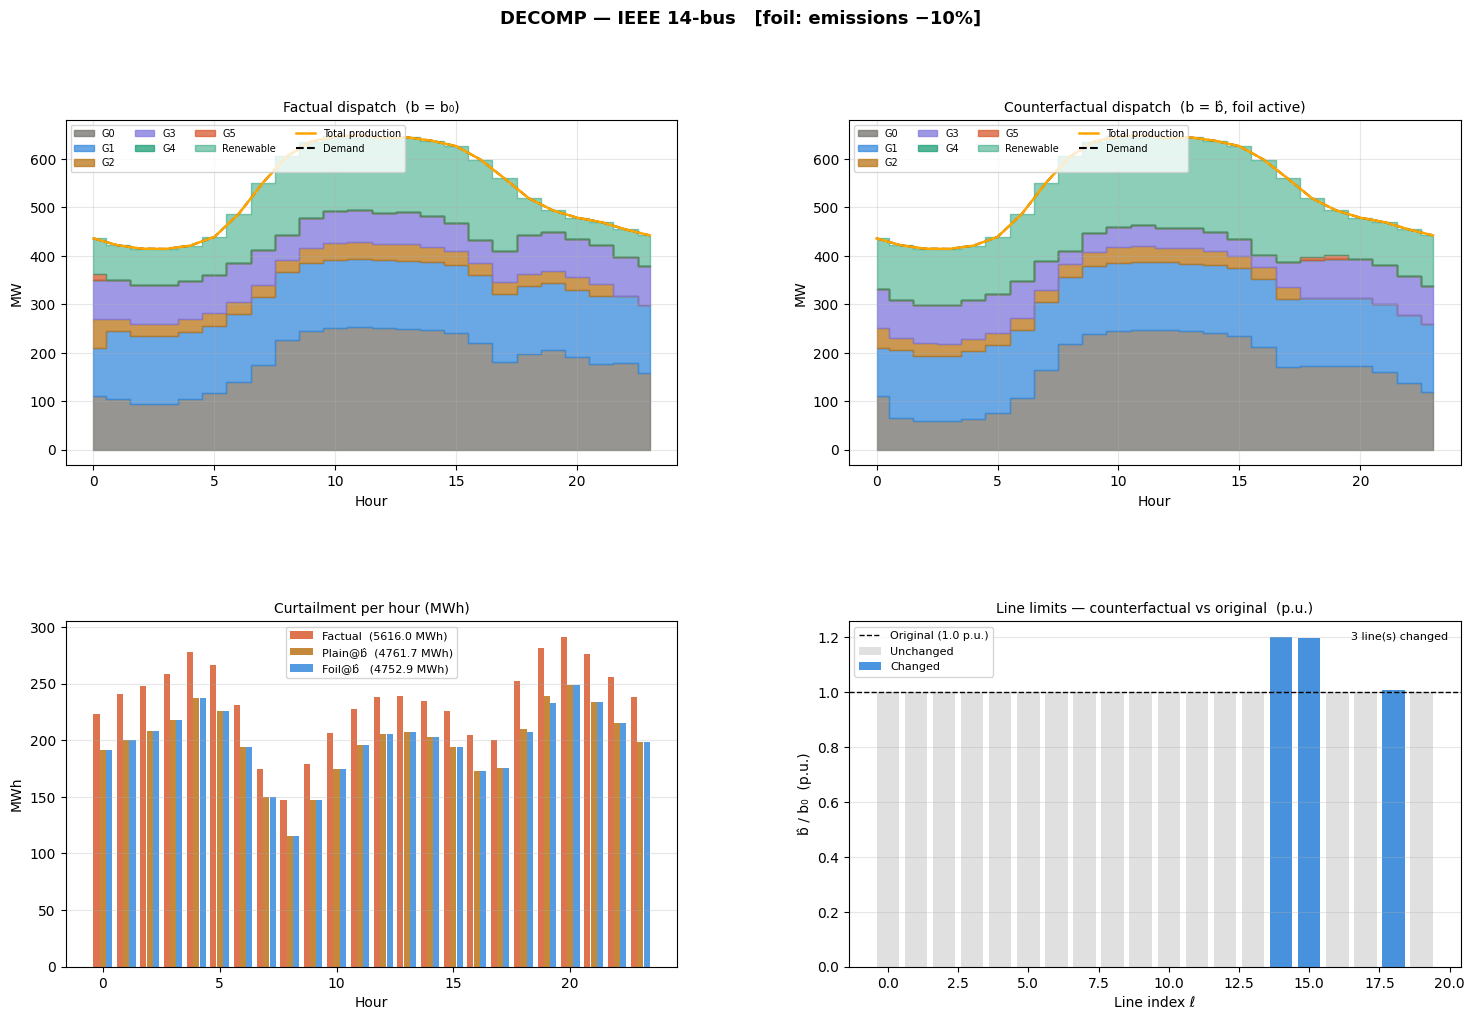


IEEE 14-bus — DECOMP summary:
  Iterations       : 2
  Patterns added   : 2
  F_opt (incumbent): 1.906642
  Master LB        : 0.935439
  Gap              : 50.938%
  Certified        : False
  Termination      : cycle
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    14   6->8       39.000      46.800     7.800       1.200    +0.200   1.000
    15   8->9       39.000      46.704     7.704       1.198    +0.198   1.000
    18  10->11      39.000      39.354     0.354       1.009    +0.009   1.000


In [15]:
res = res_14
if not res.get("success") or res.get("b_hat") is None:
    print(f"[plot] IEEE 14: no successful result — skipping plot.")
else:
    _bh = np.array(res["b_hat"], dtype=float)
    _, _, _sol_plain = oracle_14.solve_plain(_bh)
    _, _, _sol_foil  = oracle_14.solve_foil(_bh)
    plot_decomp_results(
        DATA_14, b0_14, _bh,
        sol0=solF_14,
        sol_plain_hat=_sol_plain,
        sol_foil_hat=_sol_foil,
        res=res,
        label=f"IEEE 14-bus",
        foil_label=f"emissions −{ALPHA:.0%}",
        method="DECOMP",
    )


### 4b.1b · IEEE 14-bus — ABLATION: NO warm-start (cold start)

Same as 4b.1 but `use_bs_hint=False`: no B&S CE, no `F ≤ F_hint`, no analytic warm-start.  Expected to halt after Iter 1 with `success=False` and `termination_reason='time_limit_no_incumbent'` — empirical evidence that the warm-start is structurally required, not an optimization shortcut.

In [ ]:

for _f in ["decomp_14_nohint_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_14_nohint = UCDecomp4b(
    oracle=oracle_14, data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_constr_fn=foil_fn_14,
    b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
    big_M_mu=big_M_mu_14,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_14,
    checkpoint_path="decomp_14_nohint_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="bigM",
)
res_14_nohint = decomp_14_nohint.run(
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
)
print(f"\nIEEE 14-bus | comp=bigM success={res_14_nohint['success']} F_opt={res_14_nohint['F_opt']:.4f} iters={res_14_nohint['iterations']} cert={res_14_nohint['certified']} gap={res_14_nohint['gap']:.4f} LB={res_14_nohint['master_LB']:.4f}  patterns={res_14_nohint['seen_patterns']}  big_M_mult=1.0")


### 4b.2 · IEEE 39-bus

**Step 1/3** — B&S preprocessing

In [16]:
_bs_ckpt = "bs_39_checkpoint.json"
if os.path.exists(_bs_ckpt):
    import json as _json
    with open(_bs_ckpt) as _fh:
        _cp = _json.load(_fh)
    print(f"[B&S] IEEE 39: using cached checkpoint  "
          f"(F={_cp['best_F']:.4f}, certified={_cp.get('certified')})  "
          f"— delete {_bs_ckpt!r} to re-run.")
else:
    print(f"[B&S] IEEE 39: no checkpoint — running B&S preprocessing  (max_nodes=200) ...")
    # Violation function: normalised emission excess + shed penalty
    def _make_viol_fn():
        E_f = E_factual_39; tgt = (1 - ALPHA) * E_f
        e_g = np.array([float(gen.emission_rate) for gen in DATA_39.gens])
        nB = DATA_39.nB; T = int(DATA_39.T)
        total_demand_MWh = float(np.sum(DATA_39.demand))
        def viol_fn(m, var, idx):
            s = m.addVar(lb=0.0, name="emis_viol")
            total_emis = gp.quicksum(e_g[g_] * var["p"][g_, t]
                                      for g_ in range(len(e_g)) for t in range(T))
            total_shed = gp.quicksum(var["shed"][b, t]
                                      for b in range(nB) for t in range(T))
            m.addConstr(
                s >= (total_emis - tgt) / max(E_f, 1.0)
                   + total_shed / max(total_demand_MWh, 1.0),
                name="emis_viol_constr",
            )
            m.update(); return s
        return viol_fn
    _viol_fn = _make_viol_fn()
    _bs_obj = UCBranchAndSandwichWCE_4b(
        oracle=oracle_39,
        data=DATA_39, idx=idx_39, cvec=cvec_39,
        foil_extra_constr_fn=foil_fn_39,
        b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=b_free_idx_39,
        eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
        max_nodes=200,
        relax_cost_ub=None, master_time_limit=None,
        output_flag=0, verbose=True, w=w_39,
        foil_violation_expr_fn=_viol_fn,
        lagrange_penalty=500.0,
        checkpoint_path=_bs_ckpt,
    )
    _bs_res = _bs_obj.run(
        window_size=int(DATA_39.T), per_bus_neutrality=True,
        u_init=u_init_39, p_init=p_init_39,
        on_t=on_t_39, off_t=off_t_39,
        compute_final_mip_lb=False,
    )
    if _bs_res.get("success") and _bs_res.get("best_b") is not None:
        print(f"[B&S] IEEE 39: done  F={_bs_res['F_opt']:.4f}  "
              f"nodes={_bs_res.get('nodes')}  certified={_bs_res.get('certified')}")
    else:
        # B&S failed to find a CE — fall back to bU (max expansion),
        # which is foil-feasible by construction and almost always a CE.
        # F(bU) is large but the warm-start needs ANY valid CE, not the best.
        _bU = bU_39.copy()
        _vp_bU, _, _ = oracle_39.solve_plain(_bU)
        _vd_bU, _, _ = oracle_39.solve_foil(_bU)
        if _vp_bU is not None and _vd_bU is not None and _vd_bU <= _vp_bU + 1e-3:
            _F_bU = float(np.sum(w_39[b_free_idx_39] * np.abs(
                _bU[b_free_idx_39] - b0_39[b_free_idx_39])))
            import json as _json
            with open(_bs_ckpt, "w") as _fh:
                _json.dump({
                    "best_b": _bU.tolist(),
                    "best_F": _F_bU,
                    "certified": False,
                    "fallback": "bU (max expansion); B&S found no CE",
                }, _fh)
            print(f"[B&S] IEEE 39: B&S failed — fell back to bU  "
                  f"(F={_F_bU:.4f}, v_foil={_vd_bU:.2f} ≤ v_plain={_vp_bU:.2f}, "
                  f"certified=False).  Saved synthetic checkpoint.")
        else:
            raise RuntimeError(
                f"IEEE 39: neither B&S nor bU produced a CE — "
                f"v_foil(bU)={_vd_bU} > v_plain(bU)={_vp_bU} + 1e-3.  "
                f"Check problem setup (emissions target may be infeasible at any b)."
            )


[B&S] IEEE 39: using cached checkpoint  (F=0.7138, certified=False)  — delete 'bs_39_checkpoint.json' to re-run.


**Step 2/3** — DECOMP refinement

In [17]:
_bs_hint_39 = None
_bs_ckpt_39 = "bs_39_checkpoint.json"
if os.path.exists(_bs_ckpt_39):
    import json as _json
    with open(_bs_ckpt_39) as _fh:
        _bs_cp_39 = _json.load(_fh)
    _bs_hint_39 = np.array(_bs_cp_39["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 39 (F_bs={_bs_cp_39['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_39_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_39 = UCDecomp4b(
    oracle=oracle_39, data=DATA_39, idx=idx_39, cvec=cvec_39,
    foil_extra_constr_fn=foil_fn_39,
    b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=b_free_idx_39,
    big_M_mu=big_M_mu_39,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_39,
    checkpoint_path="decomp_39_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="bigM",
    b_hat_hint=_bs_hint_39,
)
res_39 = decomp_39.run(
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39,
)
print(f"\nIEEE 39-bus | comp=bigM success={res_39['success']} F_opt={res_39['F_opt']:.4f} iters={res_39['iterations']} cert={res_39['certified']} gap={res_39['gap']:.4f} LB={res_39['master_LB']:.4f}  patterns={res_39['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 39 (F_bs=0.7138)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=292.1211  v_foil=188633.1429)
[DECOMP] b_hat hint: foil feasible (F_hint=0.7138  v_foil=421370.1793)
  [DECOMP] New incumbent: F=0.713774
[DECOMP] Initialized incumbent at b_hat_hint  (F=0.7138, v_plain=421370.1792540678, v_foil=421370.1793, oracle CE gap=-5.820766091346741e-11)
[DECOMP] Added hint upper bound: F ≤ 0.7138

[DECOMP] Iter 1/15  model: 5934 vars (720 int), 8917 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLimit  900

**Step 3/3** — Plot result

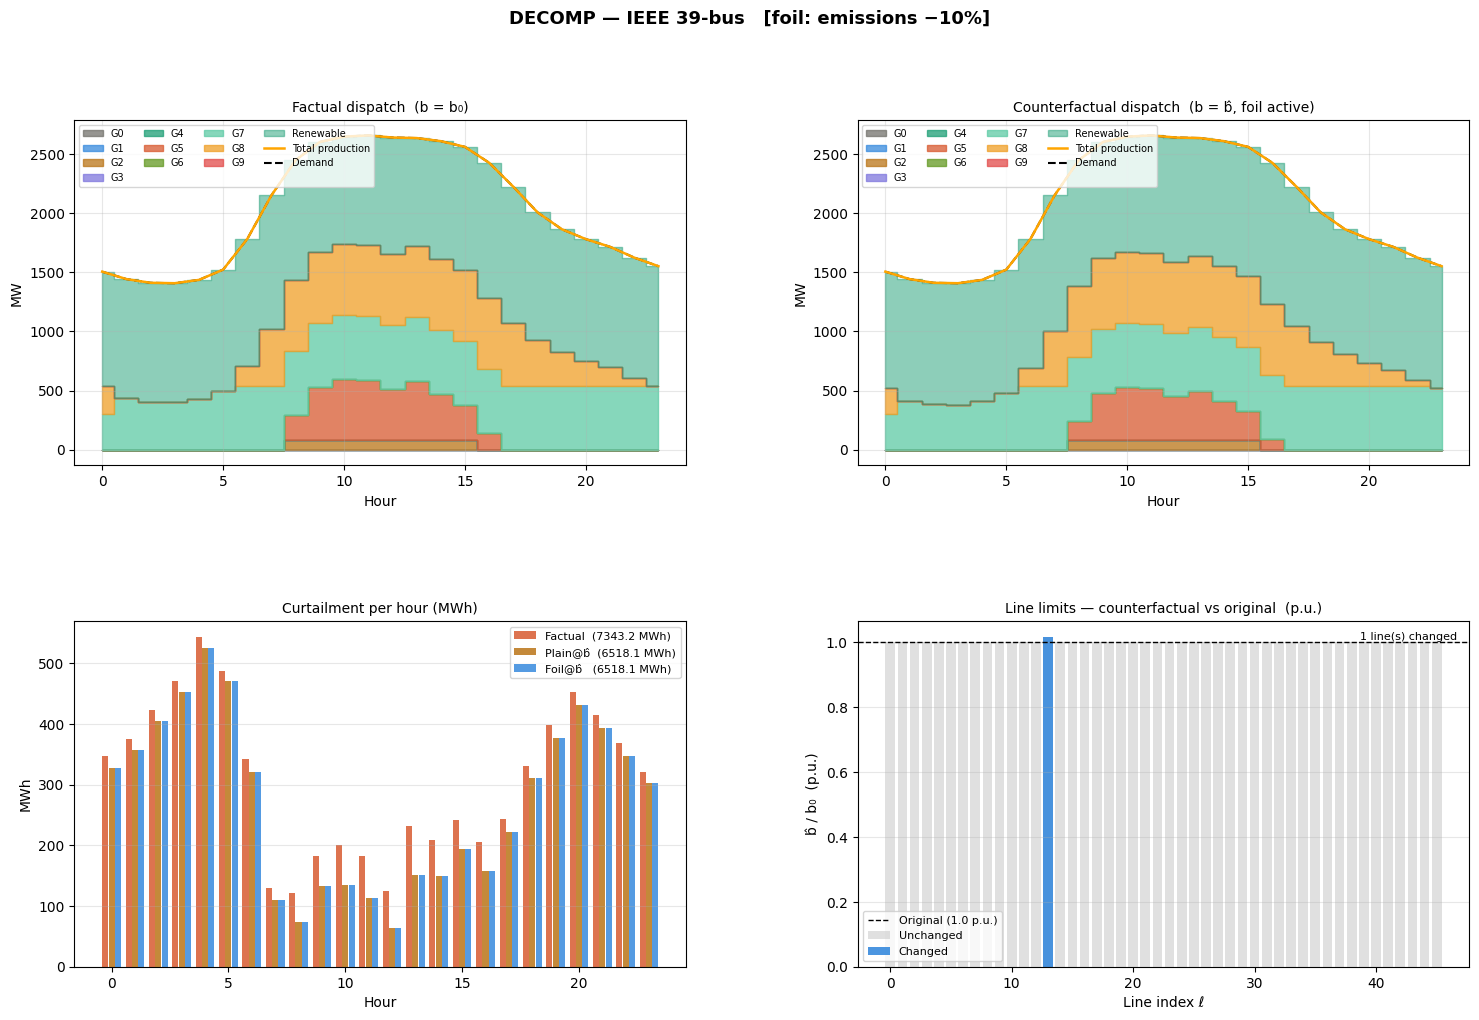


IEEE 39-bus — DECOMP summary:
  Iterations       : 1
  Patterns added   : 1
  F_opt (incumbent): 0.705998
  Master LB        : 0.000000
  Gap              : 100.000%
  Certified        : False
  Termination      : cycle
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    13   7->8      192.000     194.819     2.819       1.015    +0.015   1.000


In [18]:
res = res_39
if not res.get("success") or res.get("b_hat") is None:
    print(f"[plot] IEEE 39: no successful result — skipping plot.")
else:
    _bh = np.array(res["b_hat"], dtype=float)
    _, _, _sol_plain = oracle_39.solve_plain(_bh)
    _, _, _sol_foil  = oracle_39.solve_foil(_bh)
    plot_decomp_results(
        DATA_39, b0_39, _bh,
        sol0=solF_39,
        sol_plain_hat=_sol_plain,
        sol_foil_hat=_sol_foil,
        res=res,
        label=f"IEEE 39-bus",
        foil_label=f"emissions −{ALPHA:.0%}",
        method="DECOMP",
    )


### 4b.3 · IEEE 57-bus

**Step 1/3** — B&S preprocessing

In [19]:
_bs_ckpt = "bs_57_checkpoint.json"
if os.path.exists(_bs_ckpt):
    import json as _json
    with open(_bs_ckpt) as _fh:
        _cp = _json.load(_fh)
    print(f"[B&S] IEEE 57: using cached checkpoint  "
          f"(F={_cp['best_F']:.4f}, certified={_cp.get('certified')})  "
          f"— delete {_bs_ckpt!r} to re-run.")
else:
    print(f"[B&S] IEEE 57: no checkpoint — running B&S preprocessing  (max_nodes=200) ...")
    # Violation function: normalised emission excess + shed penalty
    def _make_viol_fn():
        E_f = E_factual_57; tgt = (1 - ALPHA) * E_f
        e_g = np.array([float(gen.emission_rate) for gen in DATA_57.gens])
        nB = DATA_57.nB; T = int(DATA_57.T)
        total_demand_MWh = float(np.sum(DATA_57.demand))
        def viol_fn(m, var, idx):
            s = m.addVar(lb=0.0, name="emis_viol")
            total_emis = gp.quicksum(e_g[g_] * var["p"][g_, t]
                                      for g_ in range(len(e_g)) for t in range(T))
            total_shed = gp.quicksum(var["shed"][b, t]
                                      for b in range(nB) for t in range(T))
            m.addConstr(
                s >= (total_emis - tgt) / max(E_f, 1.0)
                   + total_shed / max(total_demand_MWh, 1.0),
                name="emis_viol_constr",
            )
            m.update(); return s
        return viol_fn
    _viol_fn = _make_viol_fn()
    _bs_obj = UCBranchAndSandwichWCE_4b(
        oracle=oracle_57,
        data=DATA_57, idx=idx_57, cvec=cvec_57,
        foil_extra_constr_fn=foil_fn_57,
        b0=b0_57, b_bounds=(bL_57, bU_57), b_free_idx=b_free_idx_57,
        eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
        max_nodes=200,
        relax_cost_ub=None, master_time_limit=None,
        output_flag=0, verbose=True, w=w_57,
        foil_violation_expr_fn=_viol_fn,
        lagrange_penalty=500.0,
        checkpoint_path=_bs_ckpt,
    )
    _bs_res = _bs_obj.run(
        window_size=int(DATA_57.T), per_bus_neutrality=True,
        u_init=u_init_57, p_init=p_init_57,
        on_t=on_t_57, off_t=off_t_57,
        compute_final_mip_lb=False,
    )
    if _bs_res.get("success") and _bs_res.get("best_b") is not None:
        print(f"[B&S] IEEE 57: done  F={_bs_res['F_opt']:.4f}  "
              f"nodes={_bs_res.get('nodes')}  certified={_bs_res.get('certified')}")
    else:
        # B&S failed to find a CE — fall back to bU (max expansion),
        # which is foil-feasible by construction and almost always a CE.
        # F(bU) is large but the warm-start needs ANY valid CE, not the best.
        _bU = bU_57.copy()
        _vp_bU, _, _ = oracle_57.solve_plain(_bU)
        _vd_bU, _, _ = oracle_57.solve_foil(_bU)
        if _vp_bU is not None and _vd_bU is not None and _vd_bU <= _vp_bU + 1e-3:
            _F_bU = float(np.sum(w_57[b_free_idx_57] * np.abs(
                _bU[b_free_idx_57] - b0_57[b_free_idx_57])))
            import json as _json
            with open(_bs_ckpt, "w") as _fh:
                _json.dump({
                    "best_b": _bU.tolist(),
                    "best_F": _F_bU,
                    "certified": False,
                    "fallback": "bU (max expansion); B&S found no CE",
                }, _fh)
            print(f"[B&S] IEEE 57: B&S failed — fell back to bU  "
                  f"(F={_F_bU:.4f}, v_foil={_vd_bU:.2f} ≤ v_plain={_vp_bU:.2f}, "
                  f"certified=False).  Saved synthetic checkpoint.")
        else:
            raise RuntimeError(
                f"IEEE 57: neither B&S nor bU produced a CE — "
                f"v_foil(bU)={_vd_bU} > v_plain(bU)={_vp_bU} + 1e-3.  "
                f"Check problem setup (emissions target may be infeasible at any b)."
            )


[B&S] IEEE 57: using cached checkpoint  (F=11.6796, certified=None)  — delete 'bs_57_checkpoint.json' to re-run.


**Step 2/3** — DECOMP refinement

In [20]:
_bs_hint_57 = None
_bs_ckpt_57 = "bs_57_checkpoint.json"
if os.path.exists(_bs_ckpt_57):
    import json as _json
    with open(_bs_ckpt_57) as _fh:
        _bs_cp_57 = _json.load(_fh)
    _bs_hint_57 = np.array(_bs_cp_57["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 57 (F_bs={_bs_cp_57['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_57_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_57 = UCDecomp4b(
    oracle=oracle_57, data=DATA_57, idx=idx_57, cvec=cvec_57,
    foil_extra_constr_fn=foil_fn_57,
    b0=b0_57, b_bounds=(bL_57, bU_57), b_free_idx=b_free_idx_57,
    big_M_mu=big_M_mu_57,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_57,
    checkpoint_path="decomp_57_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="bigM",
    b_hat_hint=_bs_hint_57,
)
res_57 = decomp_57.run(
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57,
)
print(f"\nIEEE 57-bus | comp=bigM success={res_57['success']} F_opt={res_57['F_opt']:.4f} iters={res_57['iterations']} cert={res_57['certified']} gap={res_57['gap']:.4f} LB={res_57['master_LB']:.4f}  patterns={res_57['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 57 (F_bs=11.6796)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=44.3524  v_foil=974915.4589)
[DECOMP] b_hat hint: foil feasible (F_hint=11.6796  v_foil=1001408.2534)
  [DECOMP] New incumbent: F=11.679577
[DECOMP] Initialized incumbent at b_hat_hint  (F=11.6796, v_plain=1001408.2533994525, v_foil=1001408.2534, oracle CE gap=3.4924596548080444e-10)
[DECOMP] Added hint upper bound: F ≤ 11.6796

[DECOMP] Iter 1/15  model: 8202 vars (576 int), 12658 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLi

**Step 3/3** — Plot result

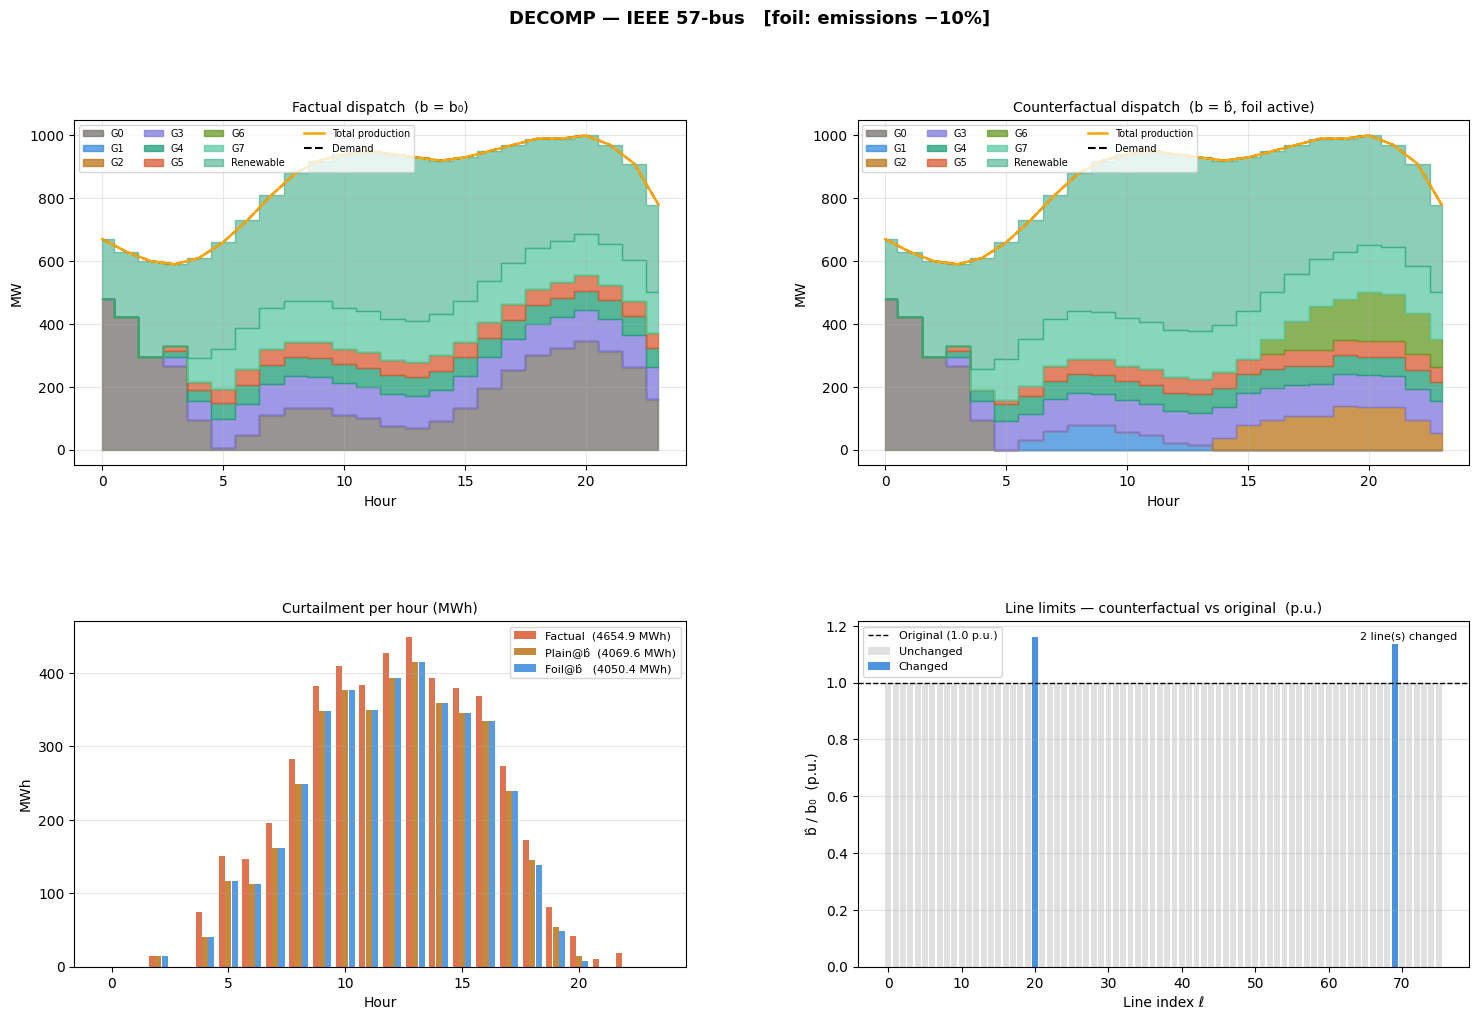


IEEE 57-bus — DECOMP summary:
  Iterations       : 2
  Patterns added   : 2
  F_opt (incumbent): 10.519222
  Master LB        : 0.000000
  Gap              : 100.000%
  Certified        : False
  Termination      : cycle
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    20  10->41     130.000     150.679    20.679       1.159    +0.159   1.000
    69  55->56     250.000     283.865    33.865       1.135    +0.135   1.000


In [21]:
res = res_57
if not res.get("success") or res.get("b_hat") is None:
    print(f"[plot] IEEE 57: no successful result — skipping plot.")
else:
    _bh = np.array(res["b_hat"], dtype=float)
    _, _, _sol_plain = oracle_57.solve_plain(_bh)
    _, _, _sol_foil  = oracle_57.solve_foil(_bh)
    plot_decomp_results(
        DATA_57, b0_57, _bh,
        sol0=solF_57,
        sol_plain_hat=_sol_plain,
        sol_foil_hat=_sol_foil,
        res=res,
        label=f"IEEE 57-bus",
        foil_label=f"emissions −{ALPHA:.0%}",
        method="DECOMP",
    )


---
## Section 4c · Fix 1: `comp_mode="hybrid"` (LB-stagnation experiment)

Same B&S warm-start pipeline as 4b, but with `comp_mode="hybrid"`: bigM is kept only for free-line flow-limit complementarity pairs (whose slack `b[ell] ± f^j` involves a master decision variable), and **all other** complementarity pairs (gen bounds, ramps, shed, curt, shift) are encoded as Gurobi indicator constraints.  Indicators are enforced by B&B branching and **do not** linearise to a loose big-M in the LP relaxation, so each new KKT block actually tightens `ObjBound` instead of being absorbed by fractional `z`s.  See `DECOMP_lb_stagnation.md` Fix 1.

Per-iteration `[LB diag]` lines (always printed in verbose mode) report `ObjBound` (CCG lower bound), `ObjVal` (incumbent upper bound), `MIPGap`, and the freshly solved Root LP value from `m.relax()`.  Compare against 4b: in bigM mode `ObjBound ≈ Root LP ≈ constant` across iterations; with hybrid we expect `ObjBound` to grow each iteration.

Results are stored in `res_14_hybrid`, `res_39_hybrid`, `res_57_hybrid` (distinct from the bigM `res_<g>` baselines).

### 4c.1 · IEEE 14-bus — hybrid

In [22]:
_bs_hint_14 = None
_bs_ckpt_14 = "bs_14_checkpoint.json"
if os.path.exists(_bs_ckpt_14):
    import json as _json
    with open(_bs_ckpt_14) as _fh:
        _bs_cp_14 = _json.load(_fh)
    _bs_hint_14 = np.array(_bs_cp_14["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 14 (F_bs={_bs_cp_14['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_14_hybrid_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_14_hybrid = UCDecomp4b(
    oracle=oracle_14, data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_constr_fn=foil_fn_14,
    b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=b_free_idx_14,
    big_M_mu=big_M_mu_14,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_14,
    checkpoint_path="decomp_14_hybrid_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="hybrid",
    b_hat_hint=_bs_hint_14,
)
res_14_hybrid = decomp_14_hybrid.run(
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
)
print(f"\nIEEE 14-bus | comp=hybrid success={res_14_hybrid['success']} F_opt={res_14_hybrid['F_opt']:.4f} iters={res_14_hybrid['iterations']} cert={res_14_hybrid['certified']} gap={res_14_hybrid['gap']:.4f} LB={res_14_hybrid['master_LB']:.4f}  patterns={res_14_hybrid['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 14 (F_bs=2.3823)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=44.6501  v_foil=802964.3015)
[DECOMP] b_hat hint: foil feasible (F_hint=2.3823  v_foil=824843.4035)
  [DECOMP] New incumbent: F=2.382312
[DECOMP] Initialized incumbent at b_hat_hint  (F=2.3823, v_plain=824843.4035337232, v_foil=824843.4035, oracle CE gap=-1.1641532182693481e-10)
[DECOMP] Added hint upper bound: F ≤ 2.3823

[DECOMP] Iter 1/15  model: 2466 vars (432 int), 3896 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLimit  900

### 4c.2 · IEEE 39-bus — hybrid

In [23]:
_bs_hint_39 = None
_bs_ckpt_39 = "bs_39_checkpoint.json"
if os.path.exists(_bs_ckpt_39):
    import json as _json
    with open(_bs_ckpt_39) as _fh:
        _bs_cp_39 = _json.load(_fh)
    _bs_hint_39 = np.array(_bs_cp_39["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 39 (F_bs={_bs_cp_39['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_39_hybrid_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_39_hybrid = UCDecomp4b(
    oracle=oracle_39, data=DATA_39, idx=idx_39, cvec=cvec_39,
    foil_extra_constr_fn=foil_fn_39,
    b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=b_free_idx_39,
    big_M_mu=big_M_mu_39,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_39,
    checkpoint_path="decomp_39_hybrid_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="hybrid",
    b_hat_hint=_bs_hint_39,
)
res_39_hybrid = decomp_39_hybrid.run(
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39,
)
print(f"\nIEEE 39-bus | comp=hybrid success={res_39_hybrid['success']} F_opt={res_39_hybrid['F_opt']:.4f} iters={res_39_hybrid['iterations']} cert={res_39_hybrid['certified']} gap={res_39_hybrid['gap']:.4f} LB={res_39_hybrid['master_LB']:.4f}  patterns={res_39_hybrid['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 39 (F_bs=0.7138)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=292.1211  v_foil=188633.1429)
[DECOMP] b_hat hint: foil feasible (F_hint=0.7138  v_foil=421370.1793)
  [DECOMP] New incumbent: F=0.713774
[DECOMP] Initialized incumbent at b_hat_hint  (F=0.7138, v_plain=421370.1792540678, v_foil=421370.1793, oracle CE gap=-5.820766091346741e-11)
[DECOMP] Added hint upper bound: F ≤ 0.7138

[DECOMP] Iter 1/15  model: 5934 vars (720 int), 8917 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLimit  900

### 4c.3 · IEEE 57-bus — hybrid

In [24]:
_bs_hint_57 = None
_bs_ckpt_57 = "bs_57_checkpoint.json"
if os.path.exists(_bs_ckpt_57):
    import json as _json
    with open(_bs_ckpt_57) as _fh:
        _bs_cp_57 = _json.load(_fh)
    _bs_hint_57 = np.array(_bs_cp_57["best_b"], float)
    print(f"[hint] B&S b_hat loaded for IEEE 57 (F_bs={_bs_cp_57['best_F']:.4f})")
else:
    print("[hint] No B&S checkpoint found — running without hint")

for _f in ["decomp_57_hybrid_checkpoint.json"]:
    if os.path.exists(_f): os.remove(_f)

decomp_57_hybrid = UCDecomp4b(
    oracle=oracle_57, data=DATA_57, idx=idx_57, cvec=cvec_57,
    foil_extra_constr_fn=foil_fn_57,
    b0=b0_57, b_bounds=(bL_57, bU_57), b_free_idx=b_free_idx_57,
    big_M_mu=big_M_mu_57,
    eps_weak=1e-3, eps_obj=1e-3, max_iter=15,
    output_flag=0, verbose=True, w=w_57,
    checkpoint_path="decomp_57_hybrid_checkpoint.json",
    big_M_multiplier=1.0,
    master_time_limit=900,
    master_output_flag=1,
    master_mip_gap=1e-4,
    comp_mode="hybrid",
    b_hat_hint=_bs_hint_57,
)
res_57_hybrid = decomp_57_hybrid.run(
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57,
)
print(f"\nIEEE 57-bus | comp=hybrid success={res_57_hybrid['success']} F_opt={res_57_hybrid['F_opt']:.4f} iters={res_57_hybrid['iterations']} cert={res_57_hybrid['certified']} gap={res_57_hybrid['gap']:.4f} LB={res_57_hybrid['master_LB']:.4f}  patterns={res_57_hybrid['seen_patterns']}  big_M_mult=1.0")


[hint] B&S b_hat loaded for IEEE 57 (F_bs=11.6796)
[DECOMP] Warm-start at b0 ...
[DECOMP] Building master ...
[DECOMP] MIP warm start: foil at bU feasible (F_ws=44.3524  v_foil=974915.4589)
[DECOMP] b_hat hint: foil feasible (F_hint=11.6796  v_foil=1001408.2534)
  [DECOMP] New incumbent: F=11.679577
[DECOMP] Initialized incumbent at b_hat_hint  (F=11.6796, v_plain=1001408.2533994525, v_foil=1001408.2534, oracle CE gap=3.4924596548080444e-10)
[DECOMP] Added hint upper bound: F ≤ 11.6796

[DECOMP] Iter 1/15  model: 8202 vars (576 int), 12658 constrs
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter MIPFocus to value 1
Set parameter NumericFocus to value 2
Set parameter TimeLimit to value 900
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Non-default parameters:
TimeLi

### 4c.4 · Comparison summary (bigM vs hybrid)
Side-by-side per-grid comparison of certified gap and final LB.  Hybrid should show strictly higher (or equal) `master_LB` and smaller `gap_pct`.

In [25]:
def _fmt(r):
    if r is None or not r.get('success'):
        return f"{'N/A':>10} {'N/A':>10} {'N/A':>8}"
    return (f"{r['F_opt']:>10.4f} {r['master_LB']:>10.4f} "
            f"{r['gap_pct']:>7.2f}%")

print(f"{'':<14} | {'=== bigM ===':^29} | {'=== hybrid ===':^29}")
print(f"{'Grid':<14} | {'F_opt':>10} {'LB':>10} {'gap%':>8} | "
      f"{'F_opt':>10} {'LB':>10} {'gap%':>8}")
print('-' * 78)
for label, r_bm, r_hy in [
    ('IEEE 14-bus', globals().get('res_14'), globals().get('res_14_hybrid')),
    ('IEEE 39-bus', globals().get('res_39'), globals().get('res_39_hybrid')),
    ('IEEE 57-bus', globals().get('res_57'), globals().get('res_57_hybrid')),
]:
    print(f'{label:<14} | {_fmt(r_bm)} | {_fmt(r_hy)}')


               |         === bigM ===          |        === hybrid ===        
Grid           |      F_opt         LB     gap% |      F_opt         LB     gap%
------------------------------------------------------------------------------
IEEE 14-bus    |     1.9066     0.9354   50.94% |     1.9067     0.9342   51.00%
IEEE 39-bus    |     0.7060     0.0000  100.00% |     0.7060     0.0000  100.00%
IEEE 57-bus    |    10.5192     0.0000  100.00% |    10.3904     0.0000  100.00%


---
## Section 5 · Results summary

In [26]:
print(f"{chr(34)*0}{"Grid":<14} {"F_opt":>10} {"Iters":>7} {"Certified":>11} {"Gap%":>8} {"Patterns":>10}")
print("-" * 64)
for label, res in [("IEEE 14-bus", res_14), ("IEEE 39-bus", res_39), ("IEEE 57-bus", res_57)]:
    cert = "YES" if res["certified"] else "NO"
    Fopt = f"{res['F_opt']:.4f}" if res["success"] else "N/A"
    gapc = f"{res['gap_pct']:.2f}%" if res["success"] else "N/A"
    print(f"{label:<14} {Fopt:>10} {res['iterations']:>7} {cert:>11} {gapc:>8} {res['seen_patterns']:>10}")


SyntaxError: f-string: expecting '}' (1275914425.py, line 1)

In [ ]:
print("\nCE verification (v_foil <= v_plain + eps):")
EPS = 1e-3
for label, res, oracle in [
    ("IEEE 14-bus", res_14, oracle_14),
    ("IEEE 39-bus", res_39, oracle_39),
    ("IEEE 57-bus", res_57, oracle_57),
]:
    if not res["success"]:
        print(f"  {label}: no CE found"); continue
    vp, _, _ = oracle.solve_plain(res["b_hat"])
    vd, _, _ = oracle.solve_foil(res["b_hat"])
    ok = vd is not None and vp is not None and vd <= vp + EPS
    print(f"  {label}: v_plain={vp:.2f}  v_foil={vd:.2f}  CE_ok={ok}")
